# Homework 07: Integration, Root Finding, and Symbolic Math

**Release Date:** Apr 23

**Due Date:** May 7 11:59 PM

**Total Points:** 100 pts

**Instructions:**
- Complete all problems in this notebook
- Show all your work with clear comments
- Format all outputs professionally with units and labels
- Test your code to ensure it runs without errors

**Submission:**
- Submit this completed Jupyter notebook to Gradescope
- Make sure all cells have been executed and outputs are visible

---

### The Big Picture

This homework follows a single chemical engineering story from start to finish.

You are designing a reactor system for the liquid-phase decomposition of species A:

$$\text{A} \xrightarrow{k} \text{B} + \text{C}$$

The four problems build on each other:

1. **Problem 1 — SymPy:** Derive the rate law and Arrhenius temperature dependence symbolically
2. **Problem 2 — Numerical Integration:** Size a plug flow reactor using the Levenspiel integral
3. **Problem 3 — Root Finding:** Find the equilibrium conversion under reversible conditions

By the end, you will have gone from raw experimental data all the way to a reactor design — using every numerical tool in your toolkit.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import quad, trapezoid, cumulative_trapezoid
from scipy.optimize import brentq, fsolve

sp.init_printing(use_unicode=True)

---
## Problem 1 (35 points) — Symbolic Mathematics with SymPy

Before running experiments, you want to set up the mathematical framework symbolically.

The reaction A → B + C follows a **power-law rate**:
$$-r_A = k \, C_A^n$$

where $n$ is the reaction order and $k$ is the rate constant. The rate constant follows the **Arrhenius equation**:
$$k(T) = A_0 \, \exp\!\left(-\frac{E_a}{RT}\right)$$

where $A_0$ is the pre-exponential factor, $E_a$ is the activation energy (J/mol), $R = 8.314$ J/mol·K, and $T$ is temperature in Kelvin.

**a) (7 pts)** Define the following SymPy symbols with appropriate assumptions, then build the symbolic expressions for $-r_A$ and $k(T)$. Print both expressions.

- `C_A`, `k_sym`, `n` — all positive
- `A0`, `Ea`, `R_sym`, `T_sym` — all positive

Print `-r_A` and `k(T)` using `sp.pprint` or just display them.

In [24]:
# Problem 1a — Define symbols and build expressions
C_A, k_sym, n = sp.symbols('C_A k n', positive=True)
A0, Ea, R_sym, T_sym = sp.symbols('A_0 E_a R T', positive=True)

k_T = A0 * sp.exp(-Ea / (R_sym * T_sym))
r_A = k_sym * C_A**n

print("Rate law  -r_A =")
sp.pprint(r_A)
print("\nArrhenius k(T) =")
sp.pprint(k_T)

Rate law  -r_A =
   n  
C_A ⋅k

Arrhenius k(T) =
    -Eₐ 
    ────
    R⋅T 
A₀⋅ℯ    


**b) (8 pts)** Compute the following derivatives **symbolically** and print each result:

- $\dfrac{d(-r_A)}{dC_A}$ — how does the rate change with concentration?
- $\dfrac{dk}{dT}$ — how does the rate constant change with temperature? (substitute $k(T)$ into the rate law first)
- $\dfrac{d^2 k}{dT^2}$ — the second derivative of $k$ with respect to $T$

For the last two, substitute the Arrhenius expression for $k$ so the result is in terms of $A_0$, $E_a$, $R$, $T$.

In [25]:
# Problem 1b — Symbolic derivatives
dr_dCA = sp.diff(r_A, C_A)
print("d(-r_A)/dC_A =")
sp.pprint(dr_dCA)

# Substitute Arrhenius k(T) into rate law for T-derivatives
r_A_T = r_A.subs(k_sym, k_T)
dk_dT = sp.diff(k_T, T_sym)
print("\ndk/dT =")
sp.pprint(sp.simplify(dk_dT))

d2k_dT2 = sp.diff(k_T, T_sym, 2)
print("\nd²k/dT² =")
sp.pprint(sp.simplify(d2k_dT2))

d(-r_A)/dC_A =
   n    
C_A ⋅k⋅n
────────
  C_A   

dk/dT =
       -Eₐ 
       ────
       R⋅T 
A₀⋅Eₐ⋅ℯ    
───────────
      2    
   R⋅T     

d²k/dT² =
                    -Eₐ 
                    ────
                    R⋅T 
A₀⋅Eₐ⋅(Eₐ - 2⋅R⋅T)⋅ℯ    
────────────────────────
          2  4          
         R ⋅T           


**c) (10 pts)** The batch reactor design equation for a constant-volume, liquid-phase system is:

$$\frac{dC_A}{dt} = r_A = -k C_A^n$$

Use `sp.dsolve` to solve this ODE **symbolically** for $C_A(t)$.

- Define `C_A_fn = sp.Function('C_A')` as the unknown function of time `t`
- Write the ODE as a SymPy `Eq` object
- Call `sp.dsolve` and print the general solution

Then apply the initial condition $C_A(0) = C_{A0}$ (define `C_A0 = sp.Symbol('C_{A0}', positive=True)`) to eliminate the integration constant and print the particular solution.

*Hint:* After calling `dsolve`, use `.rhs.subs(t, 0) - C_A0 = 0` to solve for the constant `C1`, then substitute it back.

In [26]:
# Problem 1c — Symbolic ODE solution
t = sp.Symbol('t', positive=True)
C_A_fn = sp.Function('C_A')
C_A0 = sp.Symbol('C_{A0}', positive=True)

ode = sp.Eq(C_A_fn(t).diff(t), -k_sym * C_A_fn(t)**n)
raw_sol = sp.dsolve(ode, C_A_fn(t))

# dsolve may return a list of branches when n is symbolic; take the first
general_sol = raw_sol[0] if isinstance(raw_sol, list) else raw_sol
print("General solution:")
sp.pprint(general_sol)

# Apply IC: C_A(0) = C_A0
C1 = sp.Symbol('C1')
ic_eq = general_sol.rhs.subs(t, 0) - C_A0
C1_val = sp.solve(ic_eq, C1)[0]
particular_sol = general_sol.subs(C1, C1_val)
print("\nParticular solution (C_A(0) = C_A0):")
sp.pprint(particular_sol)

General solution:
         ⎧                           -1             
         ⎪                          ─────           
         ⎪                          n - 1           
C_A(t) = ⎨(-C₁⋅n + C₁ + k⋅n⋅t - k⋅t)       for n ≠ 1
         ⎪                                          
         ⎪              nan                otherwise
         ⎩                                          

Particular solution (C_A(0) = C_A0):
         ⎧                                                                     ↪
         ⎪                                                                     ↪
         ⎪                                                                     ↪
         ⎪⎛                ⎛⎧       1 - n            ⎞   ⎛⎧       1 - n        ↪
         ⎪⎜                ⎜⎪-C_{A0}                 ⎟   ⎜⎪-C_{A0}             ↪
         ⎪⎜                ⎜⎪─────────────  for n ≠ 1⎟   ⎜⎪─────────────  for  ↪
C_A(t) = ⎨⎜k⋅n⋅t - k⋅t - n⋅⎜⎨    n - 1               ⎟ + ⎜⎨    n - 1           ↪
      

**d) (10 pts)** Use `sp.lambdify` to convert the particular solution $C_A(t)$ (for the special case $n = 1$, which gives $C_A(t) = C_{A0} e^{-kt}$ into a numerical function, then plot it.

Use these numerical values: $C_{A0} = 1.0$ mol/L, $k = 0.05$ min$^{-1}$, $t \in [0, 60]$ min.

- Plot $C_A(t)$ vs. $t$ with proper labels and title
- On the same plot, overlay the points from the experimental data below (use markers, no line):

```python
t_exp = np.array([0, 5, 10, 20, 30, 40, 50, 60])   # min
C_exp = np.array([1.00, 0.78, 0.61, 0.37, 0.22, 0.14, 0.08, 0.05])  # mol/L
```

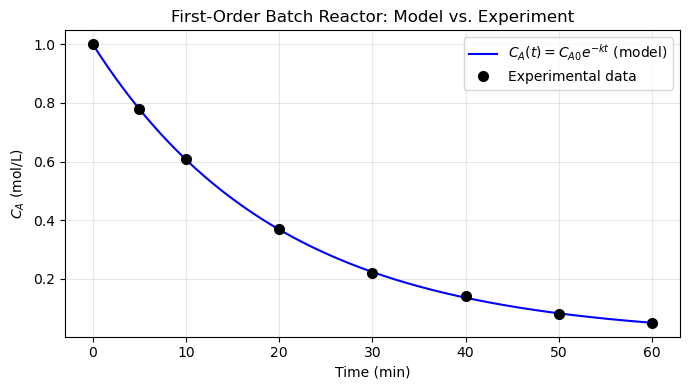

In [27]:
# Problem 1d — lambdify and plot first-order solution
t_exp = np.array([0, 5, 10, 20, 30, 40, 50, 60])   # min
C_exp = np.array([1.00, 0.78, 0.61, 0.37, 0.22, 0.14, 0.08, 0.05])  # mol/L

# Build first-order solution C_A(t) = C_A0 * exp(-k*t) symbolically
t_sym  = sp.Symbol('t', positive=True)
k_num  = sp.Symbol('k', positive=True)
CA0_sym = sp.Symbol('C_A0', positive=True)
expr_1st = CA0_sym * sp.exp(-k_num * t_sym)

CA_func = sp.lambdify((t_sym, CA0_sym, k_num), expr_1st, 'numpy')

t_plot = np.linspace(0, 60, 300)
C_plot = CA_func(t_plot, 1.0, 0.05)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t_plot, C_plot, 'b-', label=r'$C_A(t) = C_{A0}e^{-kt}$ (model)')
ax.plot(t_exp, C_exp, 'ko', markersize=7, label='Experimental data')
ax.set_xlabel('Time (min)')
ax.set_ylabel('$C_A$ (mol/L)')
ax.set_title('First-Order Batch Reactor: Model vs. Experiment')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Problem 2 (35 points) — Numerical Integration: PFR Sizing

You want to design a **plug flow reactor (PFR)** to process a continuous feed stream.

The PFR design equation is the **Levenspiel integral**:

$$V = F_{A0} \int_0^{X_f} \frac{dX}{-r_A(X)}$$

For a first-order, liquid-phase reaction with $C_A = C_{A0}(1-X)$:
$$-r_A(X) = k \, C_{A0}(1-X)$$

so the Levenspiel integrand is:
$$\frac{1}{-r_A} = \frac{1}{k \, C_{A0}(1-X)}$$

**Process parameters:**

| Parameter | Value |
|-----------|-------|
| Rate constant $k$ | 0.05 min$^{-1}$ |
| Inlet concentration $C_{A0}$ | 1.0 mol/L |
| Molar feed rate $F_{A0}$ | 2.0 mol/min |
| Target conversion $X_f$ | 80% |

**a) (7 pts)** Define the Levenspiel integrand as a Python function and plot it for $X \in [0, 0.95]$. Add a vertical dashed line at $X_f = 0.8$ and label it.

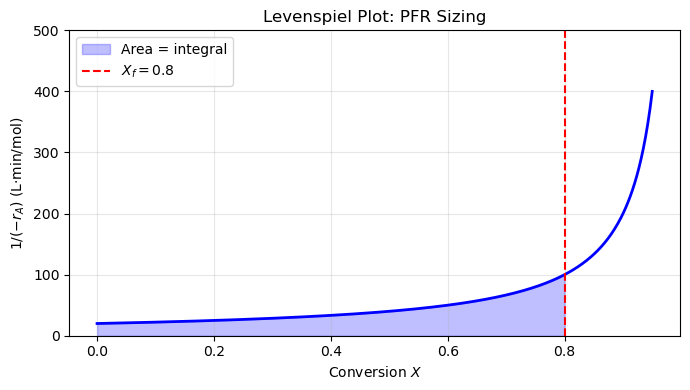

In [ ]:
# Problem 3a — Levenspiel integrand plot
k    = 0.05   # min^-1
C_A0 = 1.0    # mol/L
F_A0 = 2.0    # mol/min
X_f  = 0.80

def levenspiel(X):
    return 1.0 / (k * C_A0 * (1 - X))

X_plot = np.linspace(0, 0.95, 500) # Use this for plotting the curve

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(X_plot, levenspiel(X_plot), 'b-', linewidth=2)

X_fill = np.linspace(0, X_f, 300)
ax.fill_between(X_fill, levenspiel(X_fill), alpha=0.25, color='blue', label='Area = integral')

ax.axvline(X_f, color='red', linestyle='--', label=f'$X_f = {X_f}$')
ax.set_xlabel('Conversion $X$')
ax.set_ylabel('$1/(-r_A)$ (L·min/mol)')
ax.set_title('Levenspiel Plot: PFR Sizing')
ax.set_ylim(0, 500)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**b) (5 pts)** What happens to the integrand as $X \to 1$? Add a one-sentence observation below the plot in a markdown cell.

**Observation:** As $X \to 1$, the Levenspiel integrand $1/(-r_A) = 1/[k C_{A0}(1-X)]$ diverges to infinity because the reaction rate goes to zero and an infinite reactor volume would be required to reach complete conversion.

**c) (13 pts)** Compute the PFR volume $V = F_{A0} \int_0^{X_f} \frac{dX}{-r_A}$ using **two** numerical integration methods and compare them.

**Method 1 — Trapezoidal rule** (`scipy.integrate.trapezoid`):
- Evaluate the Levenspiel integrand at $N = 5$ evenly-spaced conversion values from 0 to $X_f$
- Compute the integral using `trapezoid(y, x)` and multiply by $F_{A0}$

**Method 2 — Adaptive quadrature** (`scipy.integrate.quad`):
- Compute the integral to near-machine precision using `quad(levenspiel, 0, X_f)`
- Multiply by $F_{A0}$

For this first-order reaction, the **exact analytical answer** is:
$$V_{\text{exact}} = \frac{F_{A0}}{k C_{A0}} \ln\!\left(\frac{1}{1-X_f}\right)$$

Print all three results (trapezoid, quad, exact) and the absolute error of each numerical method relative to the exact answer.

In [ ]:
# Problem 3b — Compare trapezoid, quad, and exact
# Method 1: Trapezoidal rule with N=5 points
X_trap = np.linspace(0, X_f, 5)
V_trap = F_A0 * trapezoid(levenspiel(X_trap), X_trap)

# Method 2: Adaptive quadrature
integral_quad, _ = quad(levenspiel, 0, X_f)
V_quad = F_A0 * integral_quad

# Exact analytical answer
V_exact = (F_A0 / (k * C_A0)) * np.log(1 / (1 - X_f))


# Use this printing format to compare results!
print(f"{'Method':<20} {'Volume (L)':>12} {'|Error| (L)':>14}")
print("-" * 48)
print(f"{'Trapezoidal (N=5)':<20} {V_trap:>12.4f} {abs(V_trap - V_exact):>14.4f}")
print(f"{'Quad (adaptive)':<20} {V_quad:>12.4f} {abs(V_quad - V_exact):>14.2e}")
print(f"{'Exact analytical':<20} {V_exact:>12.4f} {'—':>14}")

Method                 Volume (L)    |Error| (L)
------------------------------------------------
Trapezoidal (N=5)         67.3333         2.9558
Quad (adaptive)           64.3775       5.68e-14
Exact analytical          64.3775              —


**d) (10 pts)** Build a **reactor design chart** — conversion vs. volume — using `cumulative_trapezoid`.

- Evaluate the Levenspiel integrand on a fine grid of 500 conversion values from 0 to 0.95
- Use `cumulative_trapezoid(integrand, X_arr, initial=0)` to get a running integral $\int_0^X \frac{dX'}{-r_A}$
- Multiply by $F_{A0}$ to get the required volume $V(X)$ at each conversion

Then plot:
- $X$ (y-axis) vs. $V$ (x-axis), with labeled axes and a title
- A red dashed horizontal line at $X_f = 0.80$
- A red dashed vertical line at the corresponding volume $V(X_f)$

V required for X = 0.60: 36.65 L
V required for X = 0.80: 64.38 L
V required for X = 0.90: 92.11 L


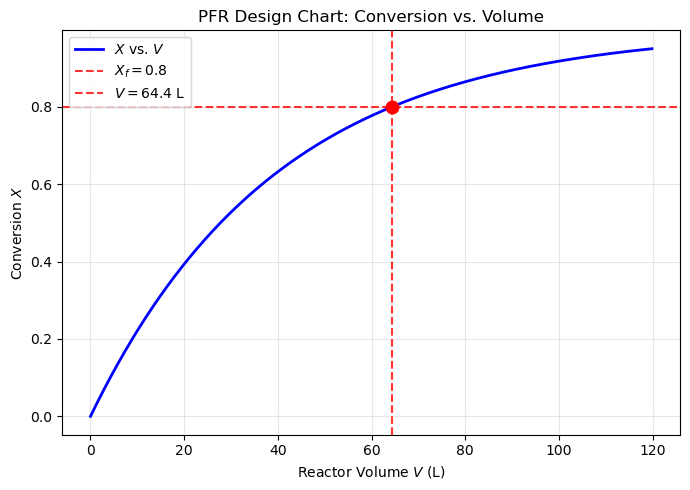

In [32]:
# Problem 3c — Reactor design chart using cumulative_trapezoid
X_arr = np.linspace(0, 0.95, 500)
integrand_arr = levenspiel(X_arr)

cum_int = cumulative_trapezoid(integrand_arr, X_arr, initial=0)
V_arr = F_A0 * cum_int

# Read off volumes at specific conversions
for X_target in [0.60, 0.80, 0.90]:
    V_target = np.interp(X_target, X_arr, V_arr)
    print(f"V required for X = {X_target:.2f}: {V_target:.2f} L")

# Volume at X_f = 0.80 for the plot marker
V_at_Xf = np.interp(X_f, X_arr, V_arr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(V_arr, X_arr, 'b-', linewidth=2, label='$X$ vs. $V$')
ax.axhline(X_f, color='red', linestyle='--', alpha=0.8, label=f'$X_f = {X_f}$')
ax.axvline(V_at_Xf, color='red', linestyle='--', alpha=0.8, label=f'$V = {V_at_Xf:.1f}$ L')
ax.plot(V_at_Xf, X_f, 'ro', markersize=9, zorder=5)
ax.set_xlabel('Reactor Volume $V$ (L)')
ax.set_ylabel('Conversion $X$')
ax.set_title('PFR Design Chart: Conversion vs. Volume')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Problem 3 (30 points) — Root Finding: Equilibrium Conversion

In practice, the decomposition A → B + C is **reversible**:

$$\text{A} \rightleftharpoons \text{B} + \text{C}$$

At equilibrium, the forward and reverse rates balance. Starting from pure A ($y_A = 1$, $y_B = y_C = 0$) and letting $X$ be the fractional conversion of A, the mole fractions at equilibrium are:

$$y_A = \frac{1 - X}{1 + X}, \qquad y_B = y_C = \frac{X}{1 + X}$$

The equilibrium condition at constant $T$ and $P$ is:

$$K_{eq} = \underbrace{\frac{y_B \, y_C}{y_A} \cdot P}_{K_p(X)} = \underbrace{\frac{\left(\dfrac{X}{1+X}\right)^2}{\dfrac{1-X}{1+X}} \cdot P}_{K_p(X)}$$

with $K_{eq} = 0.25$ at the operating temperature and $P = 2$ atm.

**Your goal:** Find the equilibrium conversion $X_e$ by solving $f(X) = K_p(X) - K_{eq} = 0$.

**a) (10 pts)** Define $K_p(X)$ and $f(X) = K_p(X) - K_{eq}$ as Python functions. Plot both using the provided code lines.

Use these plots to identify an interval $[a, b]$ such that $f(a) < 0$ and $f(b) > 0$ (or vice versa) for the following problems.

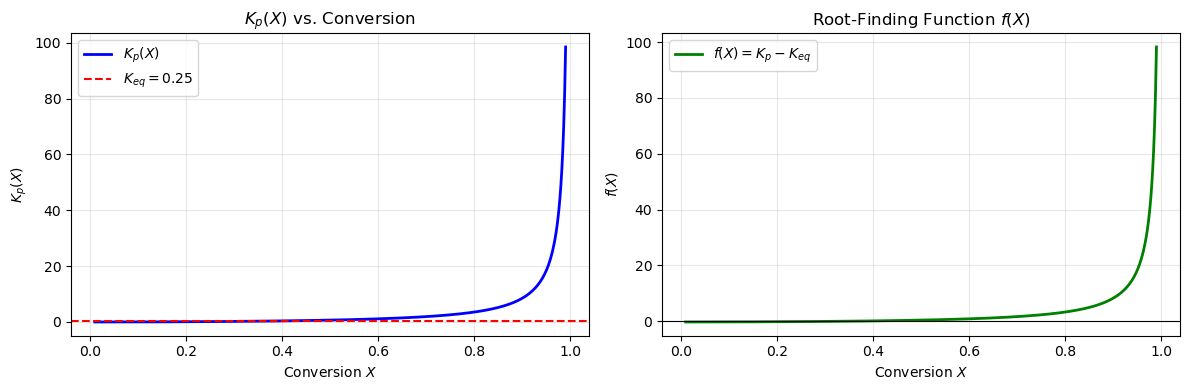

In [ ]:
# Problem 4a — Define K_p(X) and f(X), plot both
Keq = 0.25
P   = 2.0    # atm

def K_p(X, P_val=P):
    return (X / (1 + X))**2 / ((1 - X) / (1 + X)) * P_val

def f_equil(X, P_val=P):
    return K_p(X, P_val) - Keq

X_range = np.linspace(0.01, 0.99, 500)


# Use this plotting code to visualize K_p(X) and f(X) for root-finding
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(X_range, K_p(X_range), 'b-', linewidth=2, label='$K_p(X)$')
ax1.axhline(Keq, color='red', linestyle='--', label=f'$K_{{eq}} = {Keq}$')
ax1.set_xlabel('Conversion $X$')
ax1.set_ylabel('$K_p(X)$')
ax1.set_title('$K_p(X)$ vs. Conversion')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(X_range, f_equil(X_range), 'g-', linewidth=2, label='$f(X) = K_p - K_{eq}$')
ax2.axhline(0, color='k', linestyle='-', linewidth=0.8)
ax2.set_xlabel('Conversion $X$')
ax2.set_ylabel('$f(X)$')
ax2.set_title('Root-Finding Function $f(X)$')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**b) (10 pts)** Find the equilibrium conversion using `scipy.optimize.brentq`.

- Call `brentq(f_equil, a, b)` with your bracket from part (a)
- Print the equilibrium conversion $X_e$ and verify by printing $f(X_e)$ (should be $\approx 0$)
- Print the equilibrium mole fractions $y_A$, $y_B$, $y_C$
- Print a check: does $y_A + y_B + y_C = 1$? (it should)

In [34]:
# Problem 4b — brentq root finding
X_eq = brentq(f_equil, 0.01, 0.99)
print(f"Equilibrium conversion X_e = {X_eq:.4f}  ({X_eq*100:.2f}%)")
print(f"Verification f(X_e)        = {f_equil(X_eq):.2e}  (≈ 0 ✓)")

y_A = (1 - X_eq) / (1 + X_eq)
y_B = X_eq / (1 + X_eq)
y_C = X_eq / (1 + X_eq)
print(f"\nEquilibrium mole fractions:")
print(f"  y_A = {y_A:.4f}")
print(f"  y_B = {y_B:.4f}")
print(f"  y_C = {y_C:.4f}")
print(f"  y_A + y_B + y_C = {y_A + y_B + y_C:.6f}  (= 1 ✓)")

print(f"\nTarget conversion (Problem 3): X_f = 0.80 ({80:.0f}%)")
print(f"Equilibrium conversion:        X_e = {X_eq:.4f} ({X_eq*100:.2f}%)")

Equilibrium conversion X_e = 0.3333  (33.33%)
Verification f(X_e)        = -5.55e-17  (≈ 0 ✓)

Equilibrium mole fractions:
  y_A = 0.5000
  y_B = 0.2500
  y_C = 0.2500
  y_A + y_B + y_C = 1.000000  (= 1 ✓)

Target conversion (Problem 3): X_f = 0.80 (80%)
Equilibrium conversion:        X_e = 0.3333 (33.33%)


**c) (10 pts)** How does the equilibrium conversion change with pressure? According to Le Chatelier's principle, increasing pressure shifts A ⇌ B + C toward the side with fewer moles.

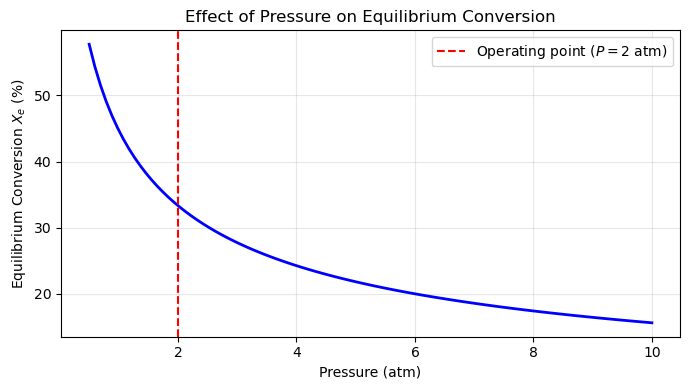

In [40]:
# Problem 4c — Equilibrium conversion vs. pressure
pressures = np.linspace(0.5, 10.0, 100)   # atm

X_eq_list = []
for P_val in pressures:
    X_e = brentq(lambda X: f_equil(X, P_val), 0.001, 0.999)
    X_eq_list.append(X_e * 100)   # convert to %

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(pressures, X_eq_list, 'b-', linewidth=2)
ax.axvline(2.0, color='red', linestyle='--', label='Operating point ($P = 2$ atm)')
ax.set_xlabel('Pressure (atm)')
ax.set_ylabel('Equilibrium Conversion $X_e$ (%)')
ax.set_title('Effect of Pressure on Equilibrium Conversion')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**d) (10 pts)** Does the trend match Le Chatelier's principle? State yes or no and explain in one sentence.

**Le Chatelier check:** Yes, the trend matches Le Chatelier's principle — increasing pressure suppresses the equilibrium conversion because A → B + C produces two moles from one, so higher pressure favors the reverse (fewer-mole) direction.



---
## Point Distribution

| Problem | Sub-parts | Total |
|---------|-----------|-------|
| Problem 1 — SymPy | a) 7 + b) 8 + c) 10 + d) 10 | **35 pts** |
| Problem 2 — Numerical Integration | a) 7 + b) 5 + c) 13 + d) 10| **35 pts** |
| Problem 3 — Root Finding | a) 10 + b) 10 + c) 10 | **30 pts** |
| **Total (without bonus)** | | **100 pts** |

Good luck!